✅ X a été chargé depuis le fichier npy.


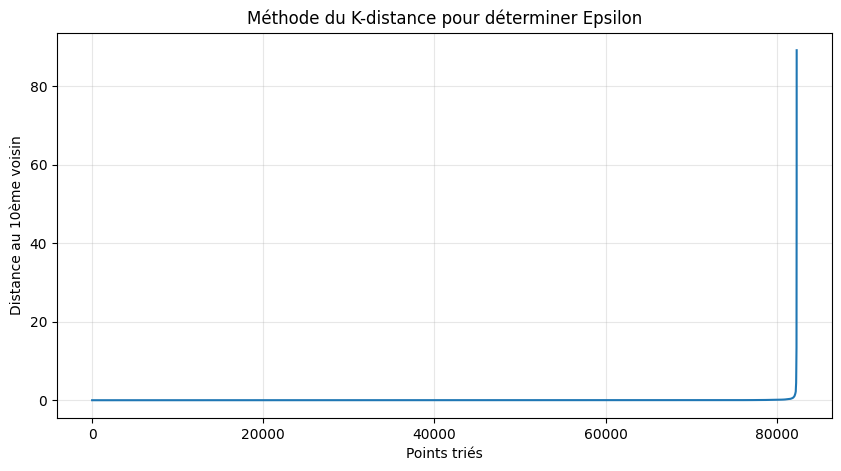

In [2]:
# %% [markdown]
# # Étape 3 : Clustering DBSCAN et Détection de Bruit
# %%
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. SÉCURITÉ : Chargement des données si elles ne sont pas là ---
OUTPUT_PATH = Path("../output")
try:
    if 'X' not in locals():
        X = np.load(OUTPUT_PATH / "X_reduced_5.npy")
        print("✅ X a été chargé depuis le fichier npy.")
except FileNotFoundError:
    print("❌ Erreur : Le fichier X_reduced_5.npy est introuvable dans /output.")

# --- 2. Recherche de l'Epsilon optimal (K-distance graph) ---
# On calcule la distance au 10ème voisin le plus proche pour chaque point
# min_samples = 10 est souvent un bon point de départ (2 * dimensions)
n_neighbors = 10
neighbors = NearestNeighbors(n_neighbors=n_neighbors)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# On trie les distances pour trouver le "coude"
distances = np.sort(distances[:, n_neighbors - 1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("Méthode du K-distance pour déterminer Epsilon")
plt.xlabel("Points triés")
plt.ylabel(f"Distance au {n_neighbors}ème voisin")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# %% [markdown]
# # Étape 3 : Clustering DBSCAN et Détection de Bruit
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from pathlib import Path

# --- 1. SÉCURITÉ : Chargement des données et bibliothèques ---
OUTPUT_PATH = Path("../output")
if 'X' not in locals():
    X = np.load(OUTPUT_PATH / "X_reduced_5.npy")

# --- 2. Exécution de DBSCAN ---
# On utilise eps=1.0 d'après ton graphique de K-distance
dbscan = DBSCAN(eps=1.0, min_samples=10)
db_labels = dbscan.fit_predict(X)

# Identification du bruit (label -1)
is_noise = (db_labels == -1)
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_ = list(db_labels).count(-1)

print(f"✅ Nombre de clusters : {n_clusters_}")
print(f"⚠️ Nombre de points de bruit : {n_noise_} ({100*n_noise_/len(X):.2f}%)")

# --- 3. Analyse : Le bruit est-il synonyme d'attaque ? ---
# y_true doit être disponible dans ton environnement
df_dbscan = pd.DataFrame({'Est_Bruit': is_noise, 'Label_Reel': y_true})
ct_dbscan = pd.crosstab(df_dbscan['Est_Bruit'], df_dbscan['Label_Reel'])

print("\n🔍 Tableau de contingence (Bruit vs Réalité) :")
print(ct_dbscan)

# --- 4. Visualisation du Bruit sur l'ACP ---
plt.figure(figsize=(12, 7))
plt.scatter(X[~is_noise, 0], X[~is_noise, 1], c='lightgrey', s=2, label='Clusters Denses')
plt.scatter(X[is_noise, 0], X[is_noise, 1], c='red', s=10, label='Bruit (Outliers)')
plt.title("DBSCAN : Identification des anomalies de bordure")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

✅ Nombre de clusters : 17
⚠️ Nombre de points de bruit : 207 (0.25%)


NameError: name 'y_true' is not defined

In [ ]:
# %%
plt.figure(figsize=(12, 7))

# Affichage des points classés en clusters (en gris)
plt.scatter(X[~is_noise, 0], X[~is_noise, 1], c='lightgrey', s=2, label='Trafic Dense')

# Affichage du bruit (en rouge)
plt.scatter(X[is_noise, 0], X[is_noise, 1], c='red', s=10, label='Bruit (Anomalies DBSCAN)')

plt.title("DBSCAN : Identification des anomalies de bordure (Bruit)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()